# FootAR - Treino Detetor de Bola v2

**Dataset:** anotacoes proprias (`player-ball-mask`)  
**Modelo:** `yolo11m` (20M params) - maior capacidade, resolucao 1280px  
**Resolucao:** 1280px - bola aparece ~40% maior que a 1024px  
**Objetivo:** mAP50 > 0.75, Recall validacao > 0.55  

Alteracoes vs treino anterior (yolo11m @ 1024):
- Resolucao maior: 1024 -> 1280px (+40% area da bola)
- copy_paste=0.5 (augmentation mais importante para objetos raros)
- degrees=0.0 (rotacao cria artefactos em 9px)
- weight_decay=0.0005 (regularizacao contra overfitting)


In [1]:
!nvidia-smi

import gc, torch
gc.collect()
torch.cuda.empty_cache()

free, total = torch.cuda.mem_get_info()
print(f'VRAM livre: {free/1024**3:.2f} GB / {total/1024**3:.2f} GB')
print(f'CUDA disponivel: {torch.cuda.is_available()}')


Mon Apr  6 21:14:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P0             20W /  140W |     627MiB /   8188MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Verificar Dataset


In [2]:
import os, glob

DATASET_PATH = r'C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask'
DATA_YAML    = os.path.join(DATASET_PATH, 'data.yaml')

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f'{split}: {imgs} imagens, {lbls} labels')

ball_count = sum(
    1 for f in glob.glob(os.path.join(DATASET_PATH, 'train', 'labels', '*.txt'))
    for line in open(f) if line.strip().startswith('0')
)
print(f'Anotacoes de bola no treino: {ball_count}')
print(f'Dataset YAML: {DATA_YAML}')


train: 708 imagens, 708 labels
valid: 202 imagens, 202 labels
test: 101 imagens, 101 labels
Anotacoes de bola no treino: 577
Dataset YAML: C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask\data.yaml


## 3. Treino - yolo11m @ 1280px

| Parametro | Valor | Razao |
|---|---|---|
| yolo11m | 20M params | Maior capacidade para features de 9px |
| imgsz=1280 | +40% resolucao | Bola: 9x12px -> 11x15px (muito mais facil detetar) |
| batch=2 | Maximo seguro | yolo11m @ 1280 usa ~6-7GB VRAM |
| copy_paste=0.5 | Alto | Duplica bolas em posicoes novas - o augmentation mais importante |
| degrees=0.0 | Desligado | Rotacao em 9px cria artefactos de interpolacao |
| mosaic=1.0 | Maximo | Cada batch ve 4x mais bolas |


In [3]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f'VRAM livre antes do treino: {free/1024**3:.2f} GB / {total/1024**3:.2f} GB')


VRAM livre antes do treino: 6.93 GB / 8.00 GB


In [4]:
from ultralytics import YOLO
import os

model = YOLO("yolo11m.pt")

print("Treino Ball v2 - yolo11m @ 1280px")
print("=" * 50)

results = model.train(
    data=DATA_YAML,
    epochs=150,
    imgsz=1280,
    batch=3,

    optimizer="SGD",
    momentum=0.937,
    lr0=0.01,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,

    device=0,
    amp=True,
    workers=0,
    classes=[0],
    patience=30,
    save_period=10,
    plots=True,
    seed=42,

    mosaic=1.0,
    close_mosaic=10,
    copy_paste=0.5,
    mixup=0.1,
    fliplr=0.5,
    scale=0.5,
    degrees=0.0,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    name="train_ball_y11m_1280",
)


Treino Ball v2 - yolo11m @ 1280px
New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.24  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[0], close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=t

## 4. Resultados


In [5]:
import csv

RUN_DIR = str(results.save_dir)
results_csv = os.path.join(RUN_DIR, 'results.csv')

with open(results_csv) as f:
    rows = list(csv.DictReader(f))

best_map50 = max(float(r['metrics/mAP50(B)']) for r in rows)
best_epoch = next(i+1 for i, r in enumerate(rows) if float(r['metrics/mAP50(B)']) == best_map50)
last = rows[-1]

print('=' * 50)
print(f'Epocas treinadas : {len(rows)}')
print(f'Melhor epoca     : {best_epoch}  (mAP50={best_map50:.3f})')
print(f'Precision final  : {float(last["metrics/precision(B)"]):.3f}')
print(f'Recall final     : {float(last["metrics/recall(B)"]):.3f}')
print(f'mAP50 final      : {float(last["metrics/mAP50(B)"]):.3f}')
print(f'mAP50-95 final   : {float(last["metrics/mAP50-95(B)"]):.3f}')
print('=' * 50)


Epocas treinadas : 141
Melhor epoca     : 116  (mAP50=0.681)
Precision final  : 0.794
Recall final     : 0.619
mAP50 final      : 0.650
mAP50-95 final   : 0.426


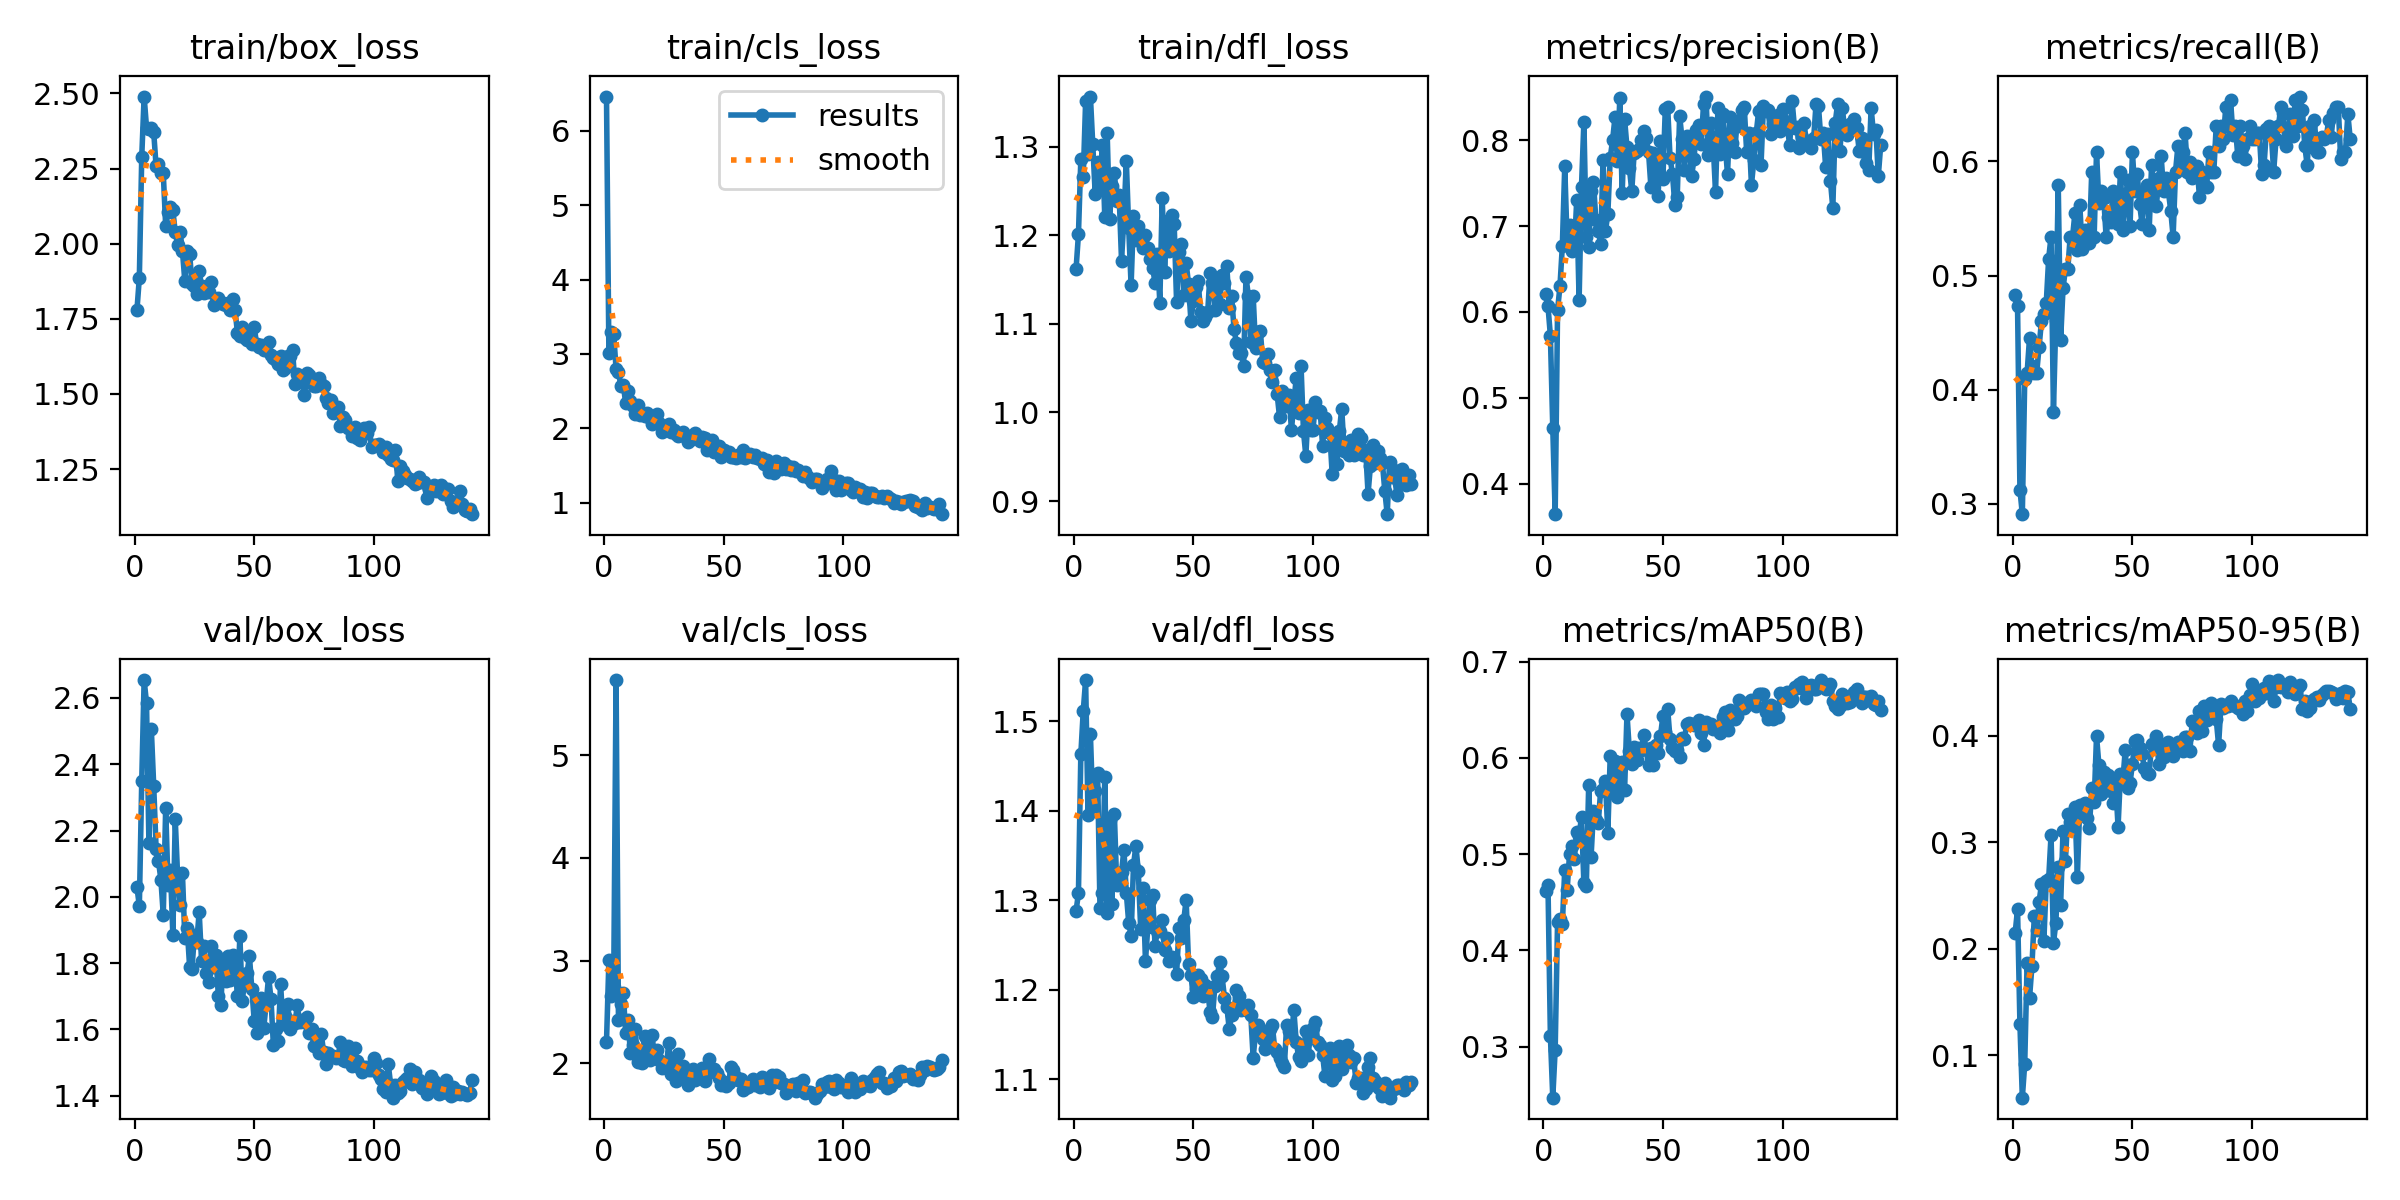

In [6]:
from IPython.display import Image, display
display(Image(filename=os.path.join(RUN_DIR, 'results.png'), width=800))


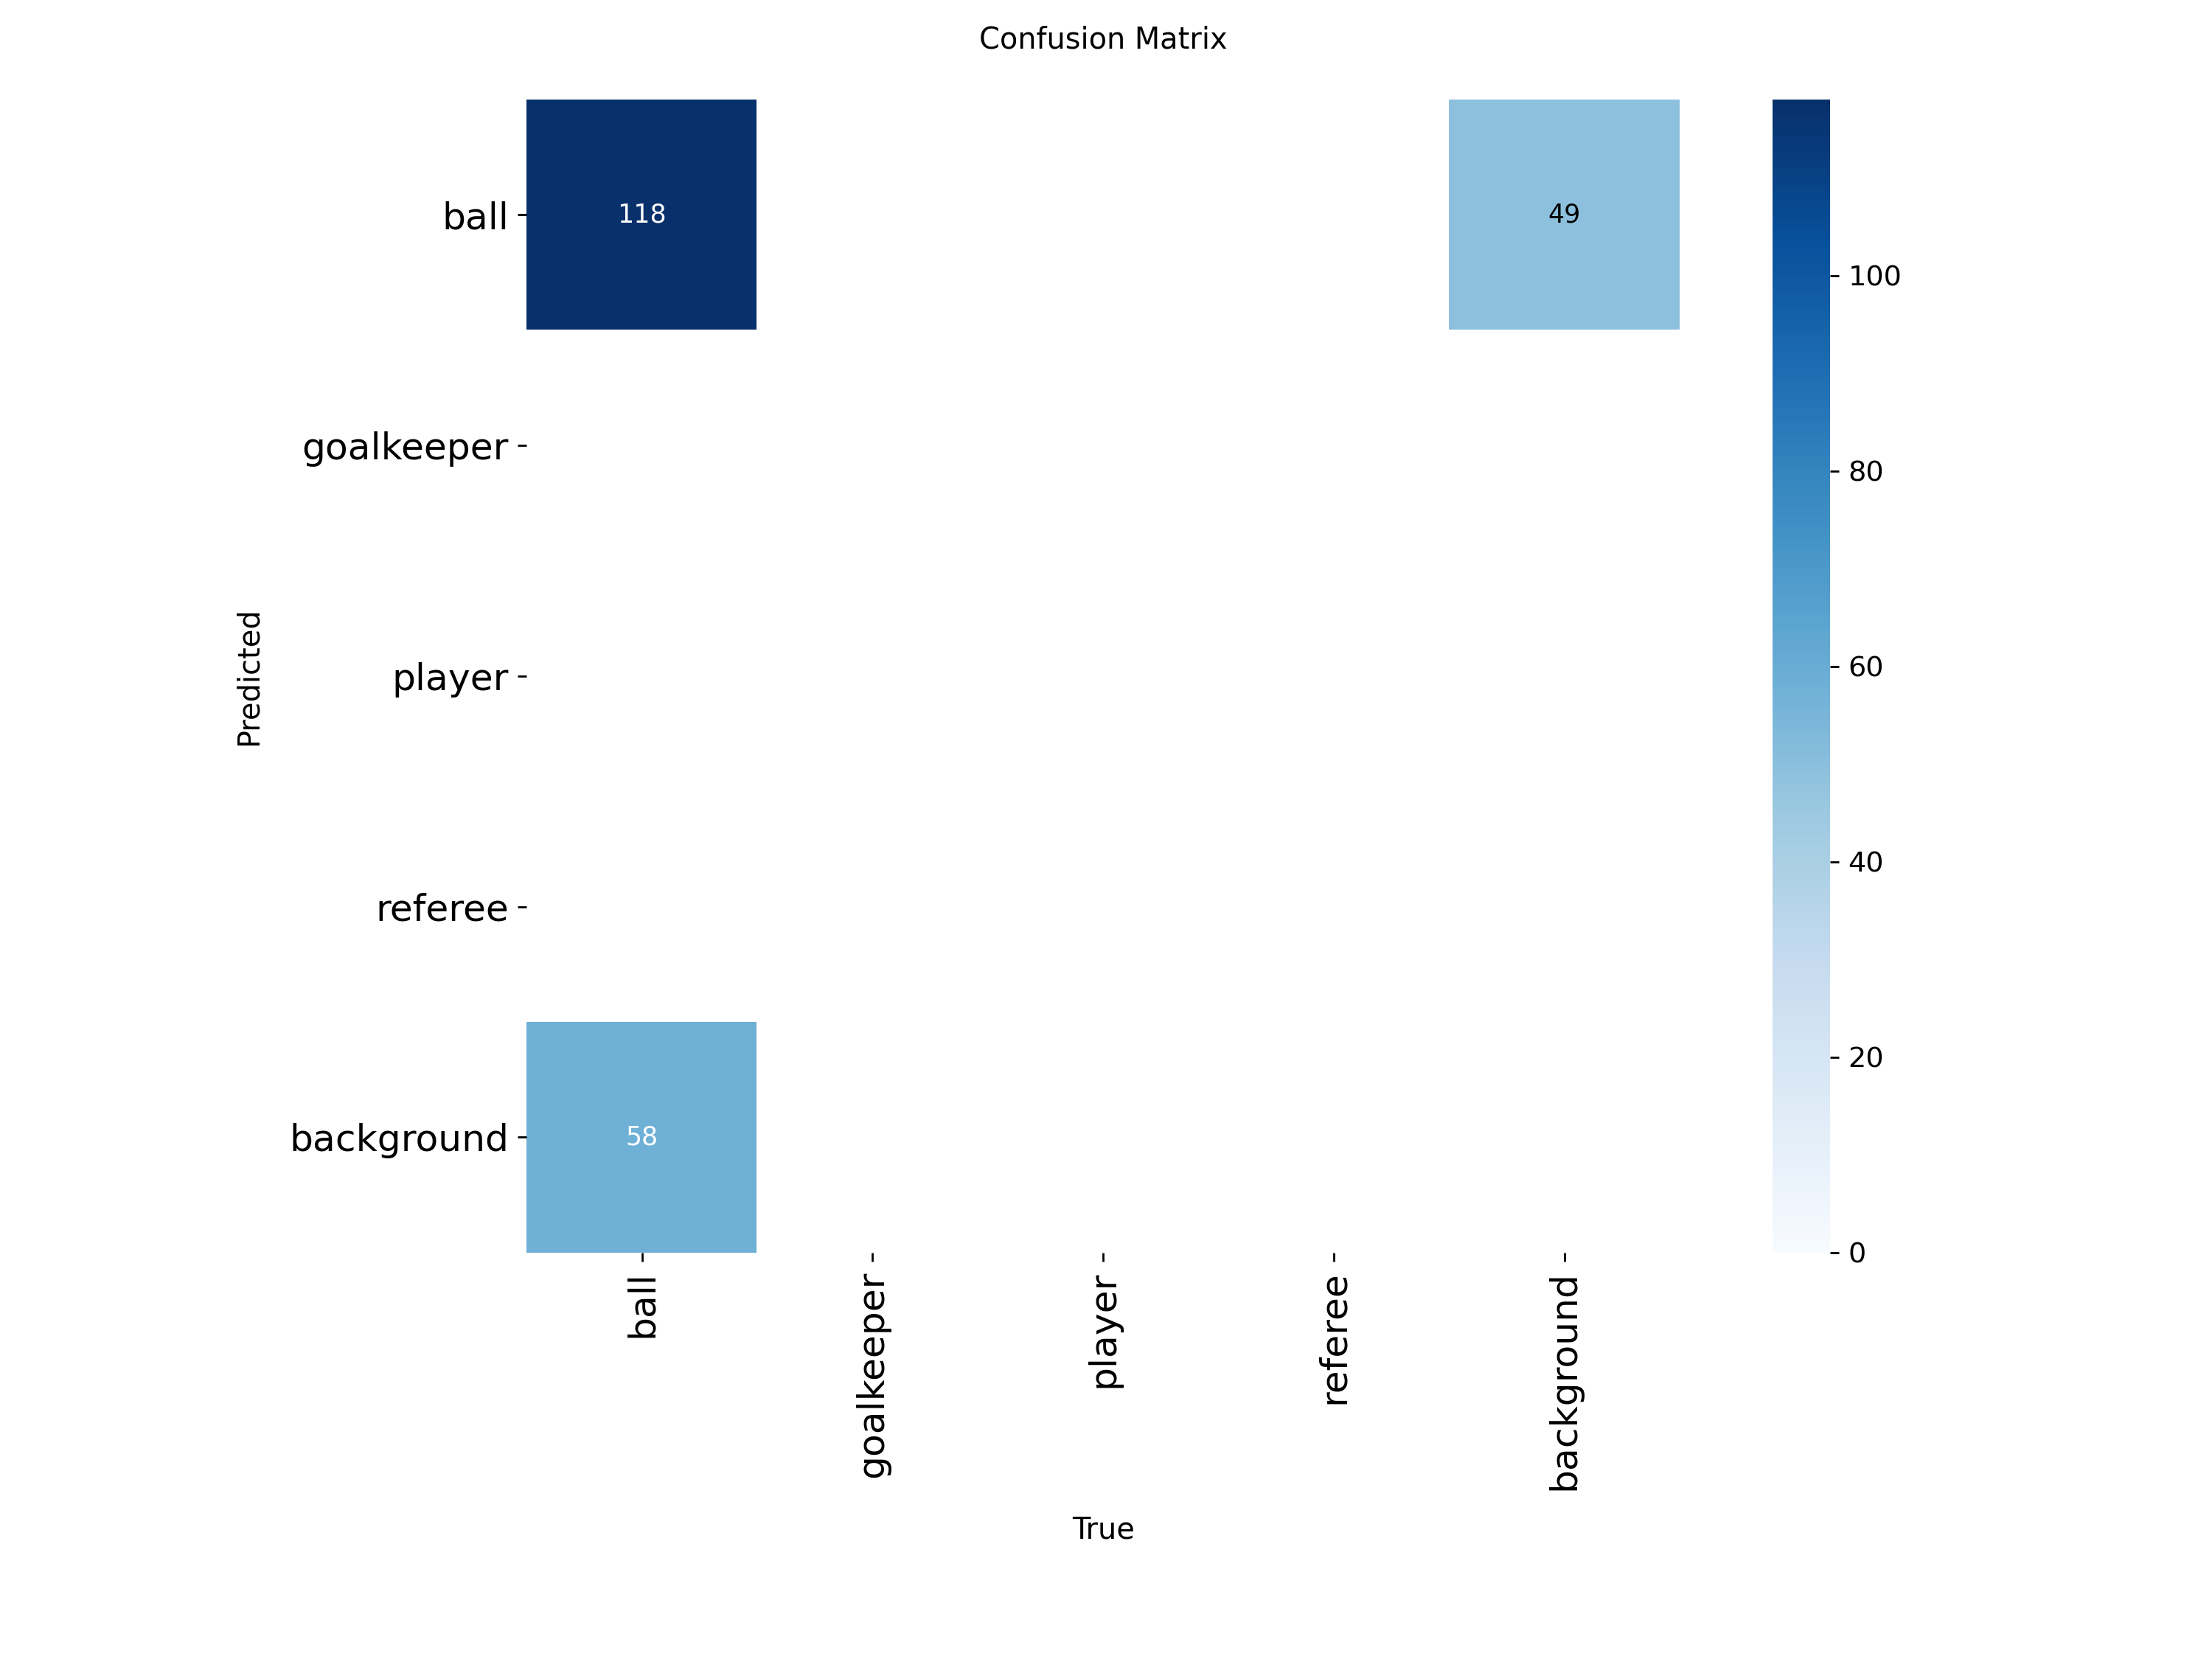

In [7]:
display(Image(filename=os.path.join(RUN_DIR, 'confusion_matrix.png'), width=600))


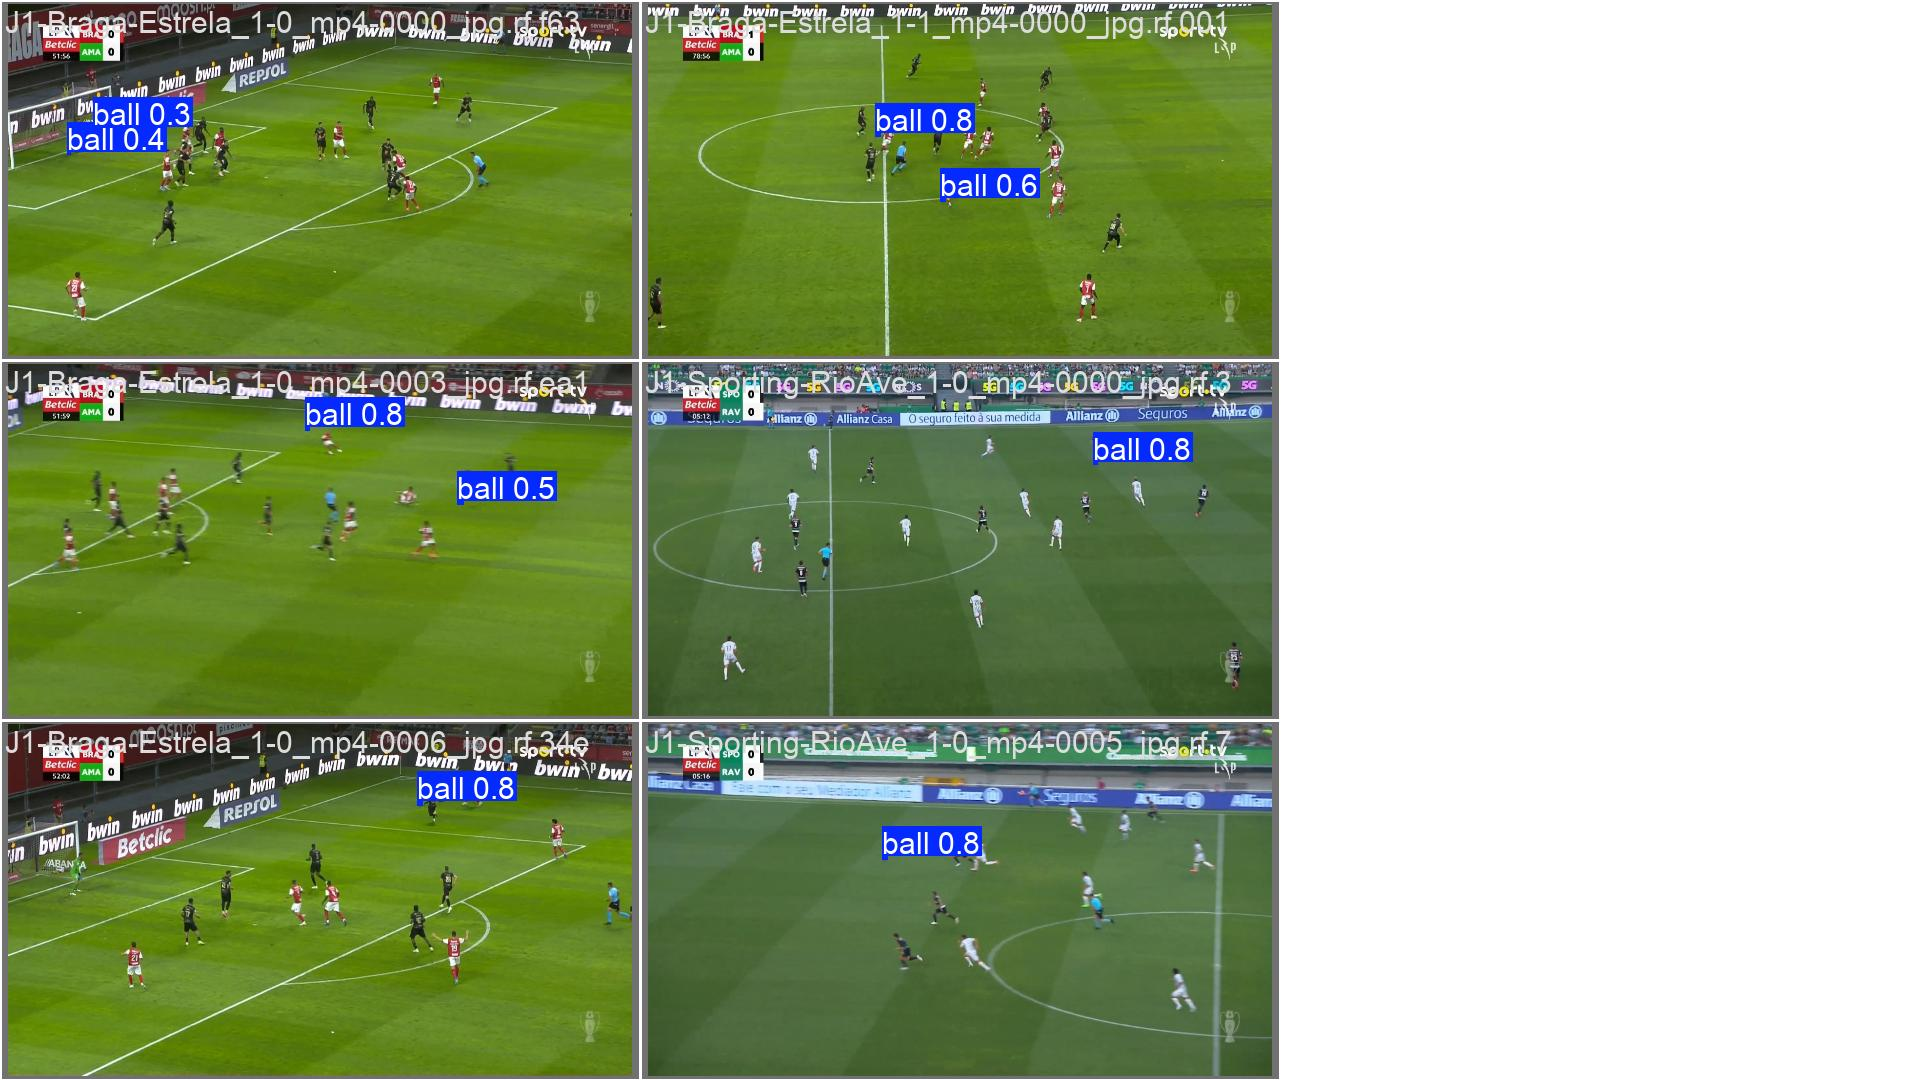

In [8]:
display(Image(filename=os.path.join(RUN_DIR, 'val_batch0_pred.jpg'), width=700))


## 5. Validacao final


In [9]:
metrics = model.val(data=DATA_YAML, imgsz=1280, batch=4, device=0, workers=0)
print(f'Ball mAP50    : {metrics.box.map50:.3f}')
print(f'Ball mAP50-95 : {metrics.box.map:.3f}')


Ultralytics 8.4.24  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1300.5319.9 MB/s, size: 177.5 KB)
val: Scanning C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask\valid\labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 5.4it/s 9.4s0.2s
                   all        202       3205      0.199      0.158      0.169      0.114
                  ball        175        176      0.795      0.631      0.675      0.457
            goalkeeper        173        173          0          0          0          0
                player        202       2633          0          0          0          0
               referee        154        223          0          0          0  

## 6. Copiar modelo para producao


In [10]:
import shutil

ACTIVE_DIR = r'C:\_FOOTAR\PD_FOOTAR\models\active'
os.makedirs(ACTIVE_DIR, exist_ok=True)

src  = os.path.join(RUN_DIR, 'weights', 'best.pt')
dest = os.path.join(ACTIVE_DIR, 'ball_y11s_footar_best.pt')

shutil.copy2(src, dest)
print(f'Modelo copiado para: {dest}')
print()
print('Para usar em main_seg.py, atualizar linha ~51:')
print("BALL_DETECTION_MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'active', 'ball_y11s_footar_best.pt')")


Modelo copiado para: C:\_FOOTAR\PD_FOOTAR\models\active\ball_y11s_footar_best.pt

Para usar em main_seg.py, atualizar linha ~51:
BALL_DETECTION_MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'active', 'ball_y11s_footar_best.pt')
